<a href="https://colab.research.google.com/github/orangegreen212/AI-Marketing-Agent-/blob/main/Coursera_Analisys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coursera Course Dataset Analysis

This notebook performs an exploratory data analysis (EDA) and visualization on the Coursera Course Dataset. The goal is to understand the characteristics of courses, their ratings, popularity, and how different attributes correlate.

---

# 1. Setup and Data Loading

First, we import the necessary libraries and load our dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
FILE_PATH = '/content/drive/MyDrive/Data for GC/Coursera_project/coursea_data.csv'
df = pd.read_csv(FILE_PATH)

In [3]:
df

,Unnamed: 0,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k
...,...,...,...,...,...,...,...
886,236,Программирование на Python,Mail.Ru Group,SPECIALIZATION,4.5,Intermediate,52k
887,883,Психолингвистика (Psycholinguistics),Saint Petersburg State University,COURSE,4.8,Mixed,21k
888,545,Разработка интерфейсов: вёрстка и JavaScript,E-Learning Development Fund,SPECIALIZATION,4.5,Intermediate,30k
889,875,Русский как иностранный,Saint Petersburg State University,SPECIALIZATION,4.6,Intermediate,9.8k


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                891 non-null    int64  
 1   course_title              891 non-null    object 
 2   course_organization       891 non-null    object 
 3   course_Certificate_type   891 non-null    object 
 4   course_rating             891 non-null    float64
 5   course_difficulty         891 non-null    object 
 6   course_students_enrolled  891 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 48.9+ KB


In [5]:
df.describe()

,Unnamed: 0,course_rating
count,891.000000,891.000000
mean,445.000000,4.677329
std,257.353842,0.162225
min,0.000000,3.300000
25%,222.500000,4.600000
50%,445.000000,4.700000
75%,667.500000,4.800000
max,890.000000,5.000000


In [6]:
df.shape

(891, 7)

In [7]:
df.columns

Index(['Unnamed: 0', 'course_title', 'course_organization',
       'course_Certificate_type', 'course_rating', 'course_difficulty',
       'course_students_enrolled'],
      dtype='object')

#2.Data Cleaning and Transformation

Based on the initial inspection, we'll perform the following cleaning steps:


*   Remove the redundant Unnamed: 0 column.
*   Convert course_students_enrolled from a string (e.g., '1.2M', '500K') to a numerical format.



    

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
course_title,0
course_organization,0
course_Certificate_type,0
course_rating,0
course_difficulty,0
course_students_enrolled,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop('Unnamed: 0', axis=1)

In [11]:
def converting(text):
    """Converts string values like '1.2k' or '5m' to numeric."""
    if pd.isna(text):
        return 0

    text = str(text).lower()
    if text.endswith('k'):
        return float(text[:-1]) * 1_000
    elif text.endswith('m'):
        return float(text[:-1]) * 1_000_000

    try:
        return float(text)
    except ValueError:
        return 0

df['course_students_enrolled'] = df['course_students_enrolled'].apply(converting)

In [12]:
df['course_Certificate_type'].unique()

array(['SPECIALIZATION', 'COURSE', 'PROFESSIONAL CERTIFICATE'],
      dtype=object)

In [13]:
df['course_difficulty'].unique()

array(['Beginner', 'Intermediate', 'Mixed', 'Advanced'], dtype=object)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   course_title              891 non-null    object 
 1   course_organization       891 non-null    object 
 2   course_Certificate_type   891 non-null    object 
 3   course_rating             891 non-null    float64
 4   course_difficulty         891 non-null    object 
 5   course_students_enrolled  891 non-null    float64
dtypes: float64(2), object(4)
memory usage: 41.9+ KB


#3. Exploratory Data Analysis (EDA) and Visualization


## Distribution of Course Ratings

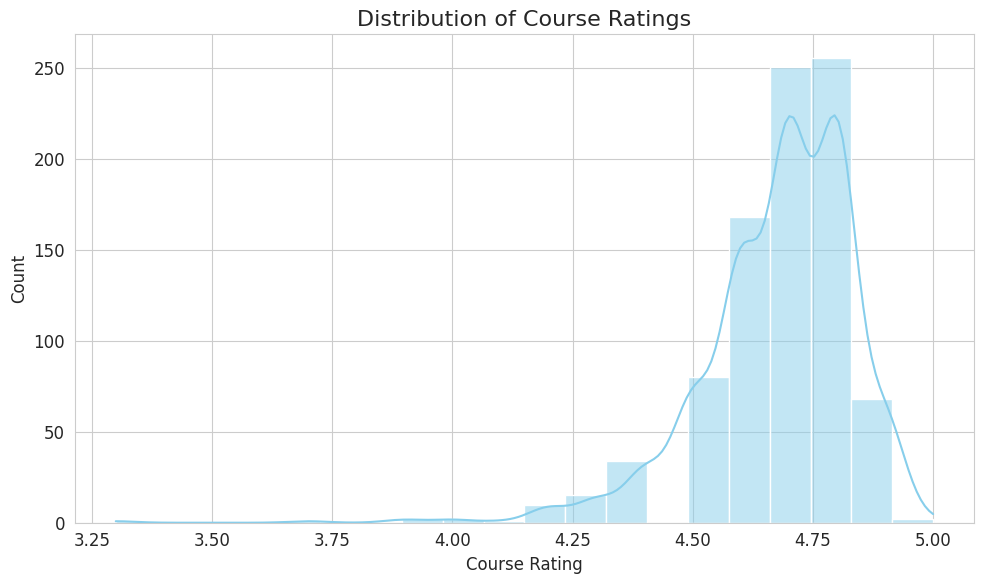

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['course_rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Course Ratings', fontsize=16)
plt.xlabel('Course Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:**  The distribution of course ratings is heavily left-skewed. The vast majority of courses have a rating between 4.5 and 5.0. This suggests that students are generally satisfied with the content, or there is a rating bias where users rarely give low scores.

## Top Course Certificate Types

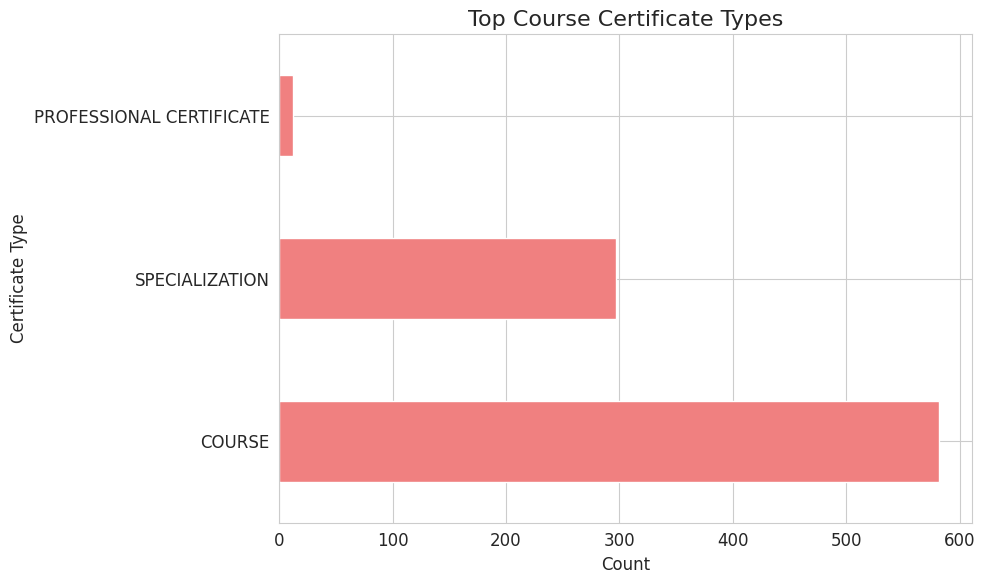

In [16]:
plt.figure(figsize=(10, 6))
df['course_Certificate_type'].value_counts().plot(kind='barh', color='lightcoral')
plt.title('Top Course Certificate Types', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Certificate Type')
plt.tight_layout()
plt.show()

**Insight:** The "Course" certificate type is by far the most common offering, followed by "Specializations". "Professional Certificates" are relatively rare, indicating that Coursera focuses more on individual skill-building modules than lengthy professional accreditations.

## Distribution courses by Difficulty Level

/tmp/ipython-input-1097462046.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='course_difficulty', data=df, palette='viridis')


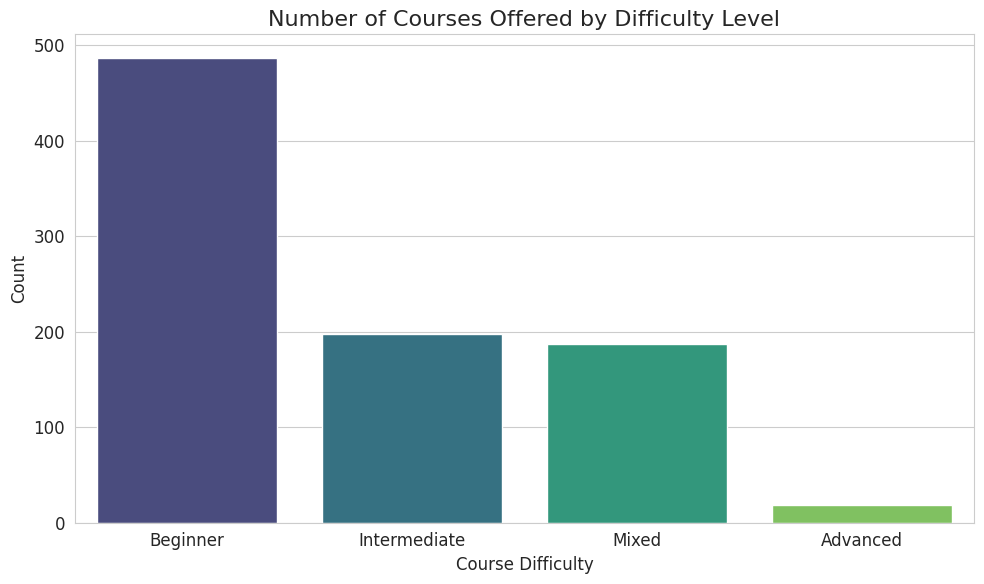

In [17]:
plt.figure(figsize=(10, 6))
# Ensure difficulty levels are ordered logically for better visualization
difficulty_order = ['Beginner', 'Intermediate', 'Mixed', 'Advanced']
df['course_difficulty'] = pd.Categorical(df['course_difficulty'], categories=difficulty_order, ordered=True)

sns.countplot(x='course_difficulty', data=df, palette='viridis')
plt.title('Number of Courses Offered by Difficulty Level', fontsize=16)
plt.xlabel('Course Difficulty')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** Beginner-level courses dominate the platform, followed by Intermediate. Advanced courses are the least common. This aligns with the platform's goal of introducing new skills to a broad audience rather than catering deeply to experts

##Top 10 Most Popular Courses by Student Enrollment

In [18]:
df.sort_values('course_students_enrolled', ascending=False).head(10)[['course_title', 'course_students_enrolled', 'course_rating']]

,course_title,course_students_enrolled,course_rating
564,Machine Learning,3200000.0,4.9
815,The Science of Well-Being,2500000.0,4.9
688,Python for Everybody,1500000.0,4.8
674,Programming for Everybody (Getting Started wit...,1300000.0,4.8
196,Data Science,830000.0,4.5
129,Career Success,790000.0,4.4
261,English for Career Development,760000.0,4.8
765,Successful Negotiation: Essential Strategies a...,750000.0,4.8
199,Data Science: Foundations using R,740000.0,4.6
211,Deep Learning,690000.0,4.8


In [19]:
px.bar(df.sort_values('course_students_enrolled', ascending=False).head(10), x='course_title', y='course_students_enrolled', title='Top 10 Courses by Student Count',
                             labels={'course_title': 'Course Title', 'course_students_enrolled': 'Number of Enrolled Students'})

**Insight:** The "Machine Learning" course is the absolute leader in popularity, significantly outperforming others. There is a massive gap between the top 1-2 courses and the rest, showing a "winner-takes-all" dynamic in student enrollment.

##Top 10 Course Organizations by Number of Courses

In [20]:
top_orgs = df['course_organization'].value_counts().head(10)
fig = px.bar(top_orgs, x=top_orgs.index, y=top_orgs.values,
             title='Top 10 Course Organizations by Number of Courses',
             labels={'x': 'Organization', 'y': 'Number of Courses'})
fig.show()

## Top 10 Highest Rated Courses

In [21]:
df.sort_values('course_rating', ascending=False).head(10)[['course_title', 'course_rating', 'course_students_enrolled']]

,course_title,course_rating,course_students_enrolled
251,El Abogado del Futuro: Legaltech y la Transfor...,5.0,1500.0
432,Infectious Disease Modelling,5.0,1600.0
82,Become a CBRS Certified Professional Installer...,4.9,210000.0
472,Introduction to Breast Cancer,4.9,27000.0
626,Neural Networks and Deep Learning,4.9,630000.0
754,Stories of Infection,4.9,28000.0
103,Build a Modern Computer from First Principles:...,4.9,95000.0
102,Bugs 101: Insect-Human Interactions,4.9,15000.0
460,International Women's Health and Human Rights,4.9,35000.0
147,Compassionate Leadership Through Service Learn...,4.9,6400.0


/tmp/ipython-input-2435543966.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




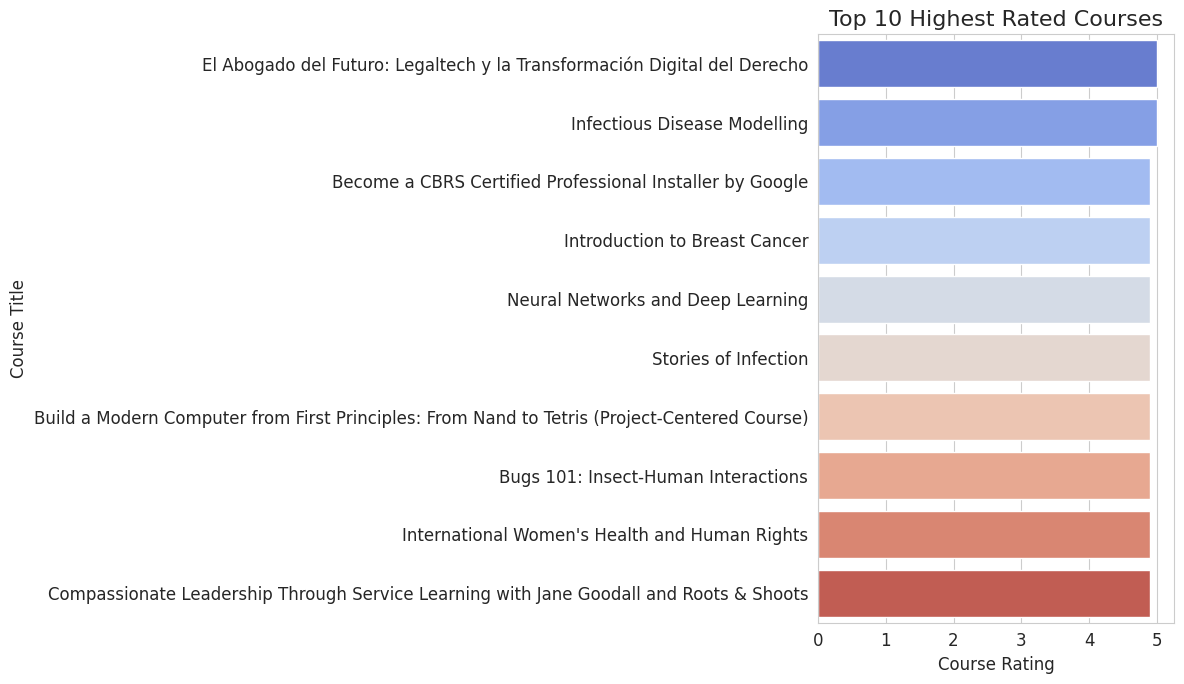


Details of Top 10 Highest Rated Courses:
                                          course_title  course_rating  \
251  El Abogado del Futuro: Legaltech y la Transfor...            5.0   
432                       Infectious Disease Modelling            5.0   
82   Become a CBRS Certified Professional Installer...            4.9   
472                      Introduction to Breast Cancer            4.9   
626                  Neural Networks and Deep Learning            4.9   
754                               Stories of Infection            4.9   
103  Build a Modern Computer from First Principles:...            4.9   
102                Bugs 101: Insect-Human Interactions            4.9   
460      International Women's Health and Human Rights            4.9   
147  Compassionate Leadership Through Service Learn...            4.9   

     course_students_enrolled             course_organization  
251                    1500.0             Universidad Austral  
432                    160

In [22]:
# Sort by course rating and take the top 10
top_10_rated_courses = df.sort_values('course_rating', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='course_rating', y='course_title', data=top_10_rated_courses, palette='coolwarm', errorbar=None)
plt.title('Top 10 Highest Rated Courses', fontsize=16)
plt.xlabel('Course Rating')
plt.ylabel('Course Title')
plt.tight_layout()
plt.show()

print("\nDetails of Top 10 Highest Rated Courses:")
print(top_10_rated_courses[['course_title', 'course_rating', 'course_students_enrolled', 'course_organization']])

 ## Relationship Between Course Rating and Difficulty

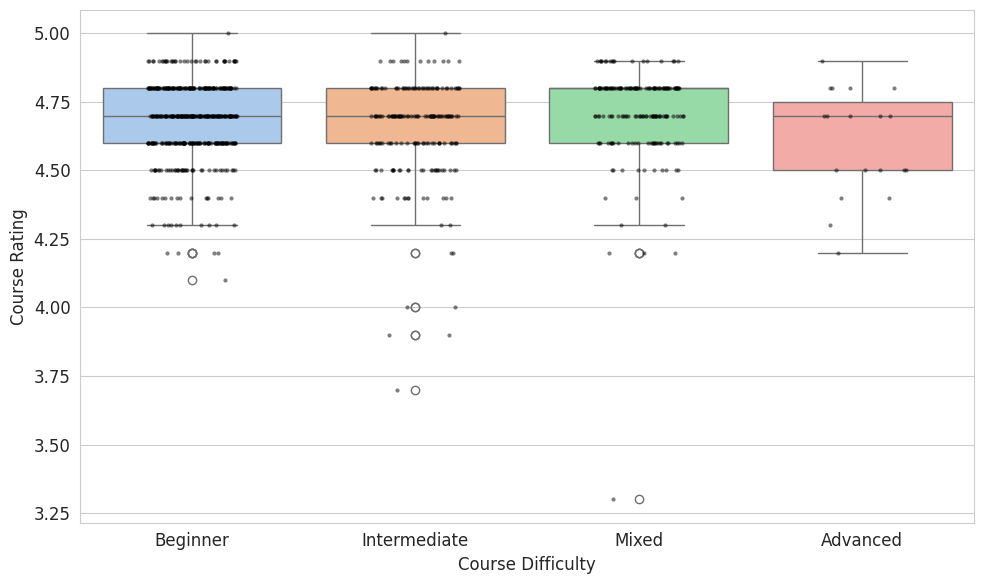

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='course_difficulty', y='course_rating', data=df,
            hue='course_difficulty', palette='pastel', order=difficulty_order, legend=False)
sns.stripplot(x='course_difficulty', y='course_rating', data=df, color='black', size=3, jitter=0.2, alpha=0.5, order=difficulty_order)
plt.xlabel('Course Difficulty')
plt.ylabel('Course Rating')
plt.tight_layout()
plt.show()

**Insight:** Beginner courses tend to have a tighter rating distribution with fewer low outliers. Advanced courses show a slightly wider range of ratings. This might indicate that advanced learners are more critical or that complex topics are harder to teach effectively to a general audience.

In [24]:

low_rating = df[df['course_rating'] == 3.3]
low_rating

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
413,How To Create a Website in a Weekend! (Project...,The State University of New York,COURSE,3.3,Mixed,140000.0


## Distribution of Students Enrolled  by Difficulty Course

Text(0, 0.5, 'Count')

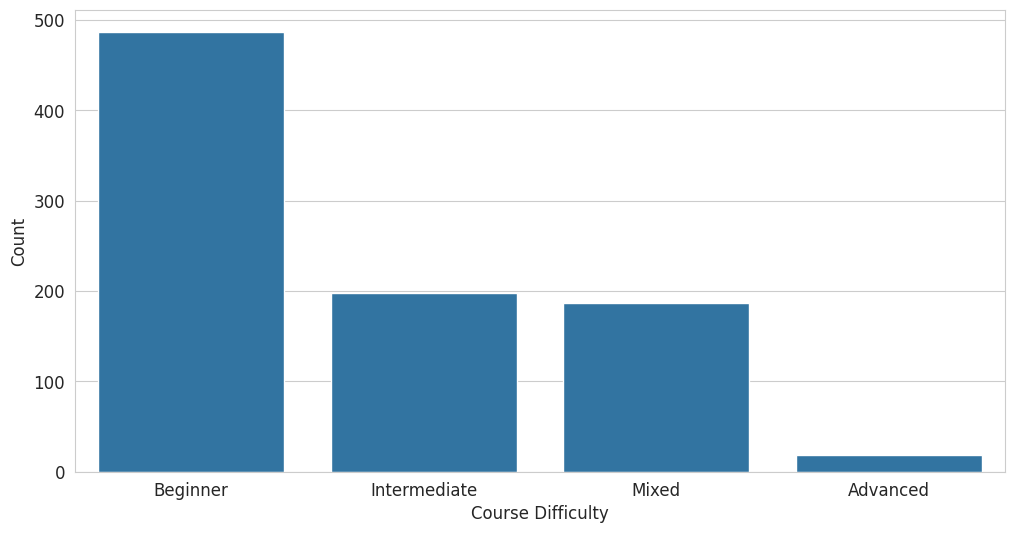

In [25]:
sns.countplot(x='course_difficulty', data=df, order=df['course_difficulty'].value_counts().index)
plt.xlabel('Course Difficulty')
plt.ylabel('Count')

In [26]:
fig_px = px.box(df,
                x='course_Certificate_type',
                y='course_rating',
                title='Boxplot of Value by Category (Plotly Express)',
                points="all",
                color='course_Certificate_type',
                labels={'course_rating': 'Course Rating', 'course_Certificate_type': 'Certificate type'}
               )

fig_px.show()

In [27]:
most_popular_course = df[df['course_students_enrolled'] ==3200000]
most_popular_course

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
564,Machine Learning,Stanford University,COURSE,4.9,Mixed,3200000.0


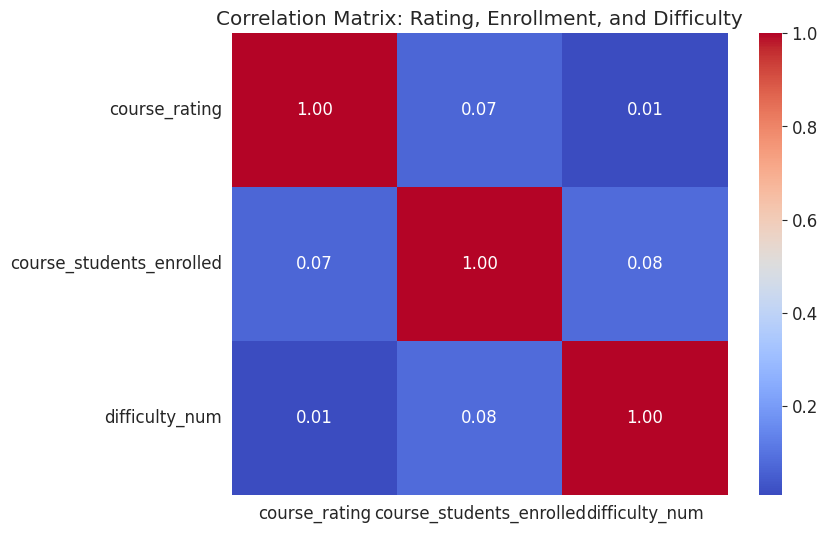

In [28]:
df['difficulty_num'] = df['course_difficulty'].map({'Beginner': 1, 'Intermediate': 2, 'Mixed': 3, 'Advanced': 4})

plt.figure(figsize=(8, 6))
# Calculate correlation matrix including difficulty
corr_matrix = df[['course_rating', 'course_students_enrolled', 'difficulty_num']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Rating, Enrollment, and Difficulty')
plt.show()

**Insight:**

There is no strong correlation between Enrollment and Rating (-0.07). A popular course isn't necessarily a higher-rated one.

There is a slight negative correlation between Difficulty and Rating. As difficulty increases, ratings tend to drop slightly, which confirms the observation from the boxplots.

#Graphs different

Text(0, 0.5, 'Count')

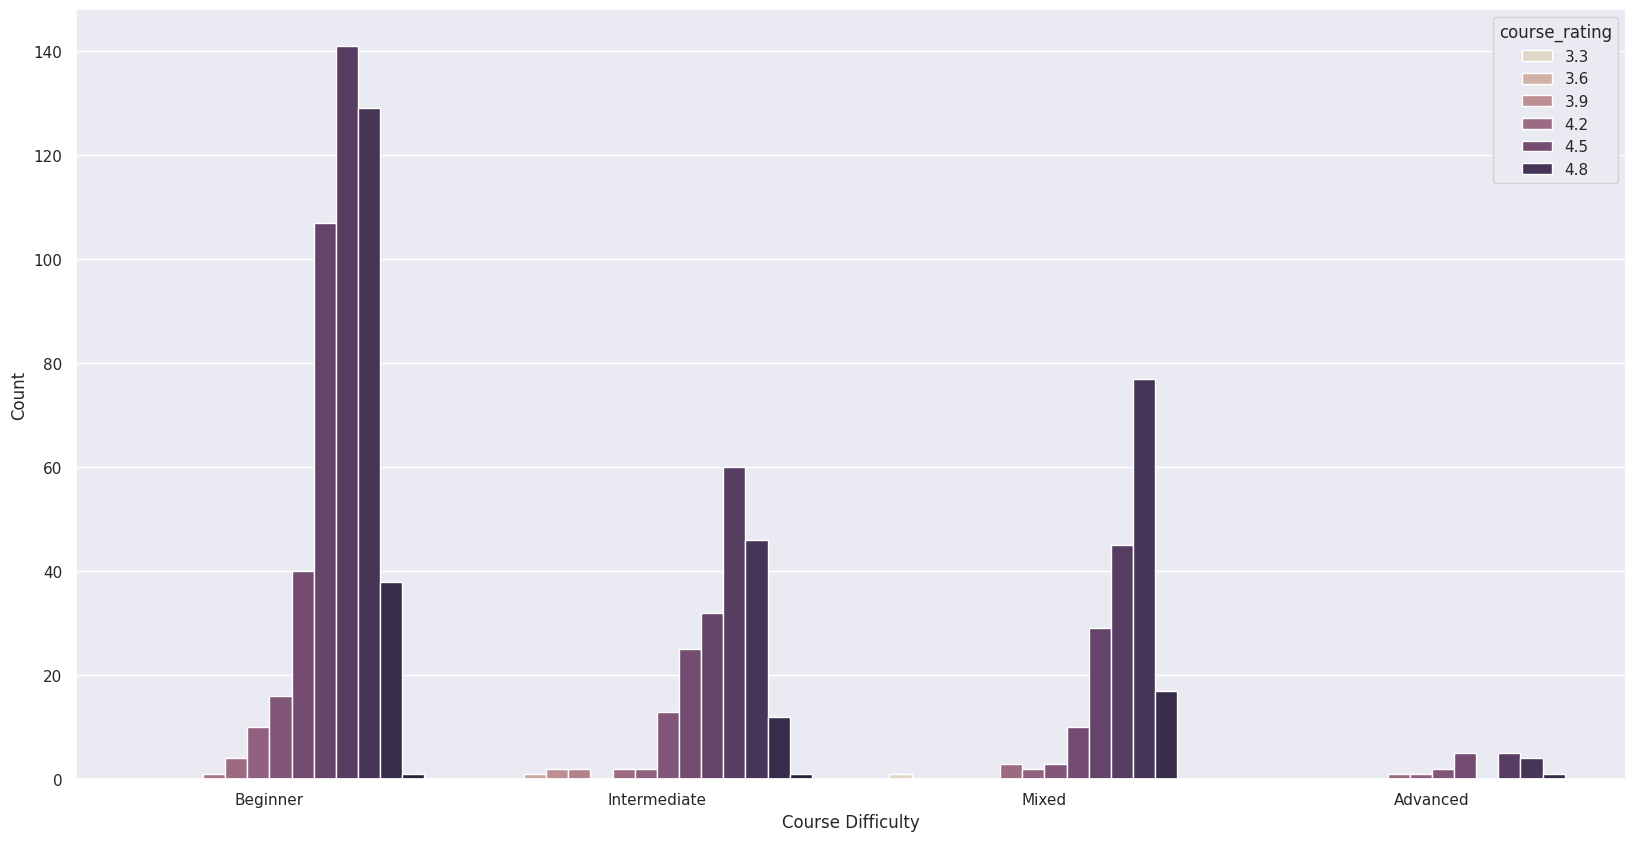

In [29]:

sns.set(rc={'figure.figsize':(20,10)})
ax=sns.countplot(data=df,hue='course_rating',x='course_difficulty',palette="ch:s=-.2,r=.6")
plt.xlabel('Course Difficulty')
plt.ylabel('Count')

Text(0, 0.5, 'Enrolled Students')

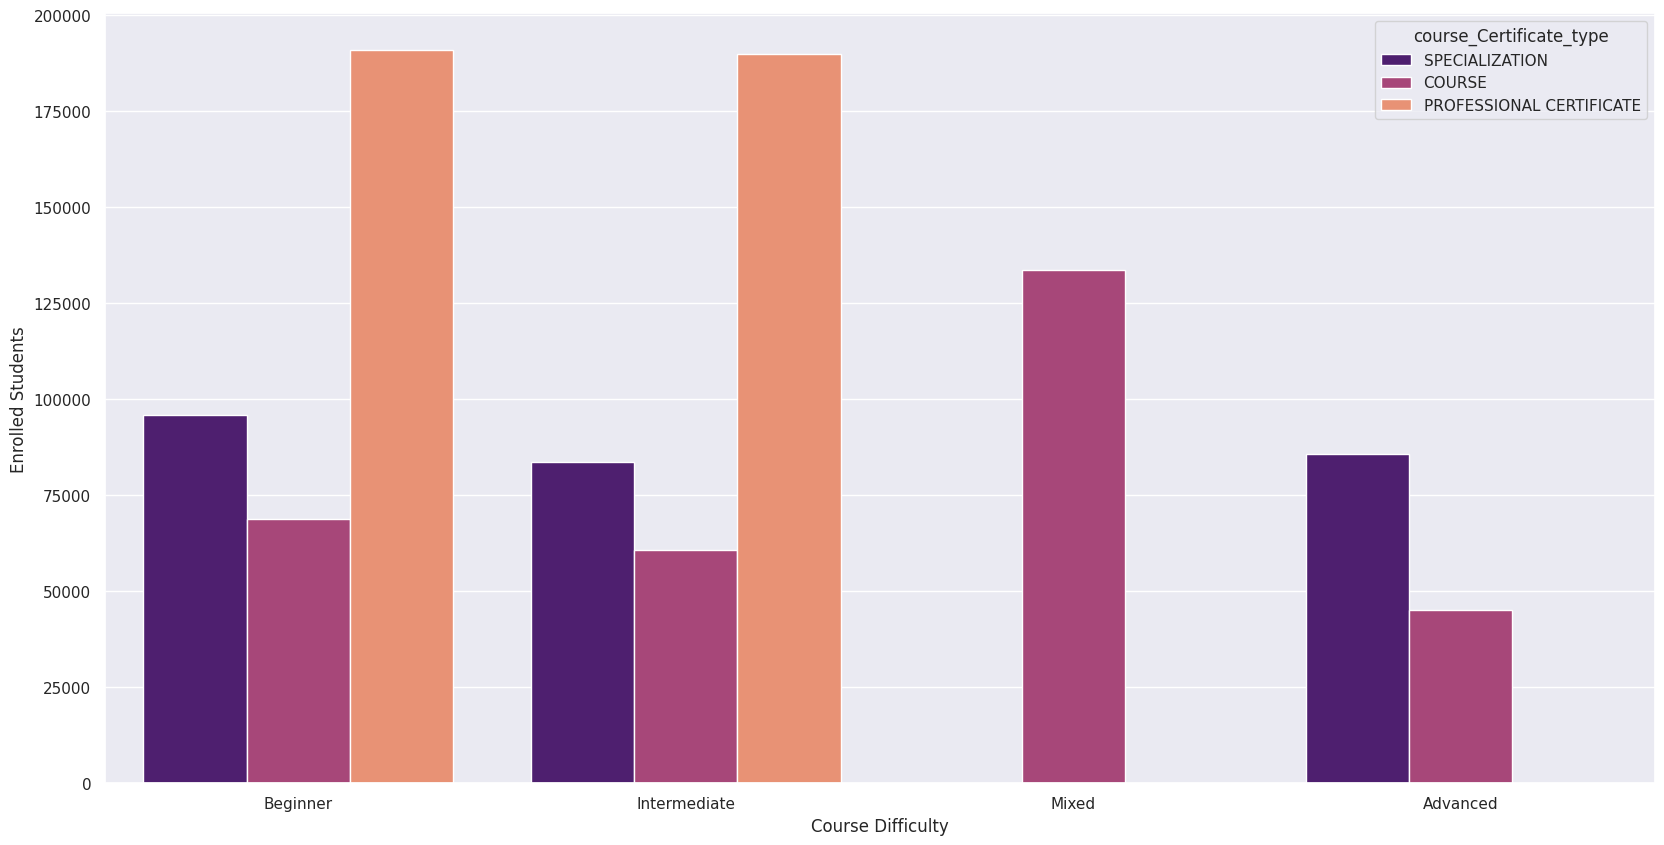

In [30]:

ax = sns.barplot(data=df,
                 hue='course_Certificate_type',
                 y='course_students_enrolled',
                 x='course_difficulty',
                 palette="magma",
                 errorbar=None,
                )
plt.xlabel('Course Difficulty')
plt.ylabel('Enrolled Students')